In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'OP', 'AD']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [5]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [6]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names = 'value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [7]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, str(resample_axis))



tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

# 主力片段拼接重采样序列文件路径 main_continuous_resampled_timeseries_path
main_continuous_resampled_timeseries_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_timeseries = pd.read_csv(main_continuous_resampled_timeseries_path, dtype = {'date': str})

In [8]:
# 同步压缩变换 SWT 数据路径 CWT_SWT_path
CWT_SWT_path = os.path.join(resample_axis_data_path, f'CWT_SWT')

# SWT 小波变换衍生特征路径 SWT_features_path
SWT_features_path = os.path.join(CWT_SWT_path, f'SWT_features.csv')
SWT_features = pd.read_csv(SWT_features_path, dtype = {'date': str})

In [9]:
# 自编码器降维路径 VAE_dimension_reduction_path
VAE_dimension_reduction_path = os.path.join(resample_axis_data_path, 'VAE_dimension_reduction')

# SWT 实部 VAE 降维路径 SWT_real_VAE_dimension_reduction_path
SWT_real_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'SWT_real_VAE_dimension_reduction')
SWT_real_latent_features_path = os.path.join(SWT_real_VAE_dimension_reduction_path, 'SWT_real_latent_features.csv')
SWT_real_latent_features = pd.read_csv(SWT_real_latent_features_path)

# SWT 虚部 VAE 降维路径 SWT_imag_VAE_dimension_reduction_path
SWT_imag_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'SWT_imag_VAE_dimension_reduction')
SWT_imag_latent_features_path = os.path.join(SWT_imag_VAE_dimension_reduction_path, 'SWT_imag_latent_features.csv')
SWT_imag_latent_features = pd.read_csv(SWT_imag_latent_features_path)

# SWT 幅值 VAE 降维路径 SWT_imag_VAE_dimension_reduction_path
SWT_magnitude_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'SWT_magnitude_VAE_dimension_reduction')
SWT_magnitude_latent_features_path = os.path.join(SWT_magnitude_VAE_dimension_reduction_path, 'SWT_magnitude_latent_features.csv')
SWT_magnitude_latent_features = pd.read_csv(SWT_magnitude_latent_features_path)

# SWT 相位 VAE 降维路径 SWT_imag_VAE_dimension_reduction_path
SWT_phase_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'SWT_phase_VAE_dimension_reduction')
SWT_phase_latent_features_path = os.path.join(SWT_phase_VAE_dimension_reduction_path, 'SWT_phase_latent_features.csv')
SWT_phase_latent_features = pd.read_csv(SWT_phase_latent_features_path)

In [10]:
# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')

# NSS 四因子模型参数路径 NSS_factors_path
NSS_factors_path = os.path.join(Nelson_Siegel_Svensson_path, f'NSS_factors.csv')
NSS_factors = pd.read_csv(NSS_factors_path)

In [11]:
# 自编码器降维路径 VAE_dimension_reduction_path
VAE_dimension_reduction_path = os.path.join(resample_axis_data_path, 'VAE_dimension_reduction')

# 主力连续差分 潜在空间 路径 close_diffed_VAE_dimension_reduction_path
close_diffed_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'close_diffed_VAE_dimension_reduction')
close_diffed_latent_features_path = os.path.join(close_diffed_VAE_dimension_reduction_path, 'close_diffed_latent_features.csv')
close_diffed_latent_features = pd.read_csv(close_diffed_latent_features_path)

# 主力连续样本熵 潜在空间 路径 close_sampen_VAE_dimension_reduction_path
close_sampen_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'close_sampen_VAE_dimension_reduction')
close_sampen_latent_features_path = os.path.join(close_sampen_VAE_dimension_reduction_path, 'close_sampen_latent_features.csv')
close_sampen_latent_features = pd.read_csv(close_sampen_latent_features_path)

# 主力连续方差 潜在空间 路径 close_variance_VAE_dimension_reduction_path
close_variance_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'close_variance_VAE_dimension_reduction')
close_variance_latent_features_path = os.path.join(close_variance_VAE_dimension_reduction_path, 'close_variance_latent_features.csv')
close_variance_latent_features = pd.read_csv(close_variance_latent_features_path)

# 主力连续 z-score 潜在空间 路径 close_zscore_VAE_dimension_reduction_path
close_zscore_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'close_zscore_VAE_dimension_reduction')
close_zscore_latent_features_path = os.path.join(close_zscore_VAE_dimension_reduction_path, 'close_zscore_latent_features.csv')
close_zscore_latent_features = pd.read_csv(close_zscore_latent_features_path)

In [12]:
# 自编码器降维路径 VAE_dimension_reduction_path
VAE_dimension_reduction_path = os.path.join(resample_axis_data_path, 'VAE_dimension_reduction')

# 近月价格差分 潜在空间 路径 near_month_price_VAE_dimension_reduction_path
near_month_price_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'near_month_price_VAE_dimension_reduction')
near_month_price_latent_features_path = os.path.join(near_month_price_VAE_dimension_reduction_path, 'near_month_price_latent_features.csv')
near_month_price_latent_features = pd.read_csv(near_month_price_latent_features_path)

# 远月价格差分 潜在空间 路径 far_month_price_VAE_dimension_reduction_path
far_month_price_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'far_month_price_VAE_dimension_reduction')
far_month_price_latent_features_path = os.path.join(far_month_price_VAE_dimension_reduction_path, 'far_month_price_latent_features.csv')
far_month_price_latent_features = pd.read_csv(far_month_price_latent_features_path)

# 近主力近月价格差分 潜在空间 路径 near_main_near_spread_VAE_dimension_reduction_path
near_main_near_spread_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'near_main_near_spread_VAE_dimension_reduction')
near_main_near_spread_latent_features_path = os.path.join(near_main_near_spread_VAE_dimension_reduction_path, 'near_main_near_spread_latent_features.csv')
near_main_near_spread_latent_features = pd.read_csv(near_main_near_spread_latent_features_path)

# 近主力远月价格差分 潜在空间 路径 near_main_far_spread_VAE_dimension_reduction_path
near_main_far_spread_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'near_main_far_spread_VAE_dimension_reduction')
near_main_far_spread_latent_features_path = os.path.join(near_main_far_spread_VAE_dimension_reduction_path, 'near_main_far_spread_latent_features.csv')
near_main_far_spread_latent_features = pd.read_csv(near_main_far_spread_latent_features_path)

In [13]:
# 预测目标数据路径 target_series_path
target_series_path = os.path.join(resample_axis_data_path, f'target_series')

# 主力连续重采样收盘价单个跨步向前差分路径 main_continuous_resampled_timeseries_close_diffed_forward_path
main_continuous_resampled_timeseries_close_diffed_forward_path = os.path.join(target_series_path, 'main_continuous_resampled_timeseries_close_diffed_forward.csv')
main_continuous_resampled_timeseries_close_diffed_forward = pd.read_csv(main_continuous_resampled_timeseries_close_diffed_forward_path)

target_series = main_continuous_resampled_timeseries_close_diffed_forward['diff_forward_1']
target_series.name = 'return'

del main_continuous_resampled_timeseries_close_diffed_forward
import gc; gc.collect()

124

In [14]:
base_len = len(main_continuous_resampled_date_index) # 基准长度
dataframe_list = [
    ("main_continuous_resampled_timeseries", main_continuous_resampled_timeseries),

    ("SWT_features", SWT_features),
    ("SWT_real_latent_features", SWT_real_latent_features),
    ("SWT_imag_latent_features", SWT_imag_latent_features),
    ("SWT_magnitude_latent_features", SWT_magnitude_latent_features),
    ("SWT_phase_latent_features", SWT_phase_latent_features),

    ("close_diffed_latent_features", close_diffed_latent_features),
    ("close_sampen_latent_features", close_sampen_latent_features),
    ("close_variance_latent_features", close_variance_latent_features),
    ("close_zscore_latent_features", close_zscore_latent_features),

    # ("NSS_factors", NSS_factors),
    ("near_month_price_latent_features", near_month_price_latent_features),
    ("far_month_price_latent_features", far_month_price_latent_features),
    # ("near_main_near_spread_latent_features", near_main_near_spread_latent_features),
    # ("near_main_far_spread_latent_features", near_main_far_spread_latent_features),

    ("target_series", target_series),
]   # 待检查对象列表 (变量名, 对象引用)


def check_dataframe_list(dataframe_list):
    check_results = []

    for name, obj in dataframe_list:
        shape = obj.shape if hasattr(obj, 'shape') else (len(obj),)
        length = shape[0]

        has_date = hasattr(obj, 'columns') and 'date' in obj.columns
        is_consistent = (length == base_len)

        # 检查最后一行是否存在 NaN（简化写法）
        try: last_row_has_nan = obj.isna().iloc[-1].any()
        except: last_row_has_nan = False

        check_results.append({
            "variable_name": name,
            "shape": str(shape),
            "row_count": length,
            "has_date_column": "True  ✅" if has_date else "False ❌",
            "is_length_consistent": "True  ✅" if is_consistent else "False ❌",
            "last_row_has_nan": "True  ⚠️" if last_row_has_nan else "False ✅",
        })

    display(pd.DataFrame(check_results))
check_dataframe_list(dataframe_list)

CTA_ML_Feature = pd.concat([objective for _, objective in dataframe_list], axis = 1)  # 使用 pd.concat 沿列方向 (axis = 1) 合并，由于长度一致且顺序相同，这相当于将它们的列拼在一起

for name, objective in dataframe_list: # 遍历原列表，删除变量引用并强制回收垃圾
    if name in globals(): del globals()[name]  # 从全局作用域删除该变量
dataframe_list.clear() # 清空列表本身，切断最后的引用
import gc; gc.collect()

,variable_name,shape,row_count,has_date_column,is_length_consistent,last_row_has_nan
0,main_continuous_resampled_timeseries,"(62838, 9)",62838,True ✅,True ✅,False ✅
1,SWT_features,"(62838, 14)",62838,False ❌,True ✅,False ✅
2,SWT_real_latent_features,"(62838, 16)",62838,False ❌,True ✅,False ✅
3,SWT_imag_latent_features,"(62838, 19)",62838,False ❌,True ✅,False ✅
4,SWT_magnitude_latent_features,"(62838, 24)",62838,False ❌,True ✅,False ✅
5,SWT_phase_latent_features,"(62838, 23)",62838,False ❌,True ✅,False ✅
6,close_diffed_latent_features,"(62838, 171)",62838,False ❌,True ✅,False ✅
7,close_sampen_latent_features,"(62838, 10)",62838,False ❌,True ✅,False ✅
8,close_variance_latent_features,"(62838, 25)",62838,False ❌,True ✅,False ✅
9,close_zscore_latent_features,"(62838, 28)",62838,False ❌,True ✅,False ✅


0

In [15]:
columns_to_drop = ['open', 'high', 'low', 'close', 'volume', 'money']
existing_cols = [col for col in columns_to_drop if col in CTA_ML_Feature.columns]

CTA_ML_Feature = CTA_ML_Feature.drop(columns = existing_cols, errors = 'ignore') # 一次性删除，避免重复列名导致的 KeyError

In [16]:
import lightgbm as lgb
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

from utils_02_LightGBM import tune_hyperparameters, train_final_model

In [17]:
def prepare_data(
    DataFrame, target_col = 'return', drop_col = ['date', ], split_index = 56612
):
    print(f"原始数据形状: {DataFrame.shape}")

    train_raw = DataFrame.iloc[:split_index].copy()
    test_raw = DataFrame.iloc[split_index:].copy()
    train = train_raw.dropna(axis = 0) # dropna 分别在训练集和测试集中删除缺失值
    test = test_raw.dropna(axis = 0)

    print(f"训练集清洗后形状: {train.shape} (原始切片: {train_raw.shape})")
    print(f"测试集清洗后形状: {test.shape} (原始切片: {test_raw.shape})")

    feature_cols = DataFrame.columns.difference([target_col] + drop_col)
    X_train, y_train = train[feature_cols], train[target_col]
    X_test, y_test = test[feature_cols], test[target_col]

    print(f"最终特征矩阵 - 训练集: {X_train.shape}, 测试集: {X_test.shape}")
    print()
    print(f"训练集时间范围: {train.iloc[0]['date']} 到 {train.iloc[-1]['date']}")
    print(f"测试集时间范围: {test.iloc[0]['date']} 到 {test.iloc[-1]['date']}")
    print()
    print(f"训练集 Index 范围: {train.index[0]} 到 {train.index[-1]}")
    print(f"测试集 Index 范围: {test.index[0]} 到 {test.index[-1]}")

    return train, test, X_train, X_test, y_train, y_test

# 数据切割 划分训练集与测试集
train, test, X_train, X_test, y_train, y_test = prepare_data(

    DataFrame = CTA_ML_Feature,
    target_col = 'return',
    drop_col = ['date'],
    split_index = 56612
)

原始数据形状: (62838, 436)
训练集清洗后形状: (55612, 436) (原始切片: (56612, 436))
测试集清洗后形状: (6225, 436) (原始切片: (6226, 436))
最终特征矩阵 - 训练集: (55612, 434), 测试集: (6225, 434)

训练集时间范围: 2015-03-31 11:12:00 到 2023-12-29 14:12:00
测试集时间范围: 2023-12-29 14:45:00 到 2025-12-31 14:06:00

训练集 Index 范围: 1000 到 56611
测试集 Index 范围: 56612 到 62836


In [18]:
# LightGBM 模型超参数寻优结果路径 LightGBM_optuna_path
LightGBM_optuna_path = os.path.join(resample_axis_data_path, "LightGBM_optuna")
os.makedirs(LightGBM_optuna_path, exist_ok = True)

# optuan 寻优实验记录路径 optuna_study_trials_path
optuna_study_trials_path = os.path.join(LightGBM_optuna_path, f"optuna_study_trials.csv")


if os.path.exists(optuna_study_trials_path):
    study_trials_df = pd.read_csv(optuna_study_trials_path, dtype = {'duration_str': str})
else:
    # 贝叶斯超参数寻优 hyperparameter optimizion framework
    tuning_results = tune_hyperparameters(
        X_train = X_train,
        y_train = y_train,
        n_trials = 20,
        n_splits = 5,
        param_space = {

            'learning_rate': (0.0005, 0.5, 'log'),      # 学习率 learning_rate，对数尺度采样
            'num_leaves': (10, 500, 'int'),             # 叶子节点数量 num_leaves，控制模型复杂度
            'max_depth': (2, 100, 'int'),               # 树的最大深度 max_depth，防止过拟合
            'min_child_samples': (5, 200, 'int'),       # min_child_samples 叶子节点最少样本数
            'subsample': (0.3, 1.0, 'float'),           # subsample 训练样本采样比例
            'colsample_bytree': (0.6, 1.0, 'float'),    # colsample_bytree 特征采样比例

            'reg_alpha': (1e-8, 20, 'log'),         # L1 reg_alpha 正则化系数
            'reg_lambda': (1e-8, 20, 'log'),        # L2 reg_lambda 正则化系数

            'max_bin': (50, 2000, 'int'),       # max_bin 直方图装箱数
            'min_data_in_bin': (1, 50, 'int'),  # min_data_in_bin 每箱最少数据量
        },
    )

    study_trials = tuning_results['study'].trials
    study_trials_list = []
    for trial in study_trials:

        row = {
            "number": trial.number,
            "value": trial.value,
            "params": trial.params,     # params 字典
            "duration_str": str(trial.duration), # 转换为可读字符串 (如 "0:20:51.510072")
        }
        study_trials_list.append(row)

    study_trials_df = pd.DataFrame(study_trials_list)

    # 储存迭代早停轮数 best_iterations
    best_iterations = tuning_results['best_iterations']
    study_trials_df['best_iterations'] = [best_iterations[i: i + 5] for i in range(0, len(best_iterations), 5)]

    study_trials_df.to_csv(optuna_study_trials_path, index = False)
    import gc; gc.collect()

In [19]:
best_idx = study_trials_df['value'].idxmin()

best_params = study_trials_df.loc[best_idx, 'params']
if isinstance(best_params, str): best_params = ast.literal_eval(best_params)

best_iterations = study_trials_df.loc[best_idx, 'best_iterations']
if isinstance(best_iterations, str): best_iterations = ast.literal_eval(best_iterations)
best_iteration = best_iterations[-1]

train_final_model(
    X_train, y_train,
    X_test, y_test,
    best_params,
    best_iteration,
)
# 使用最佳参数训练最终模型
final_results = train_final_model(
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    best_params = best_params,
    best_iteration = best_iteration,
)

In [20]:
# final_results['feature_importance'].to_csv(r"C:\Users\dell\Desktop\tmp_features.csv")
import gc; gc.collect()

89

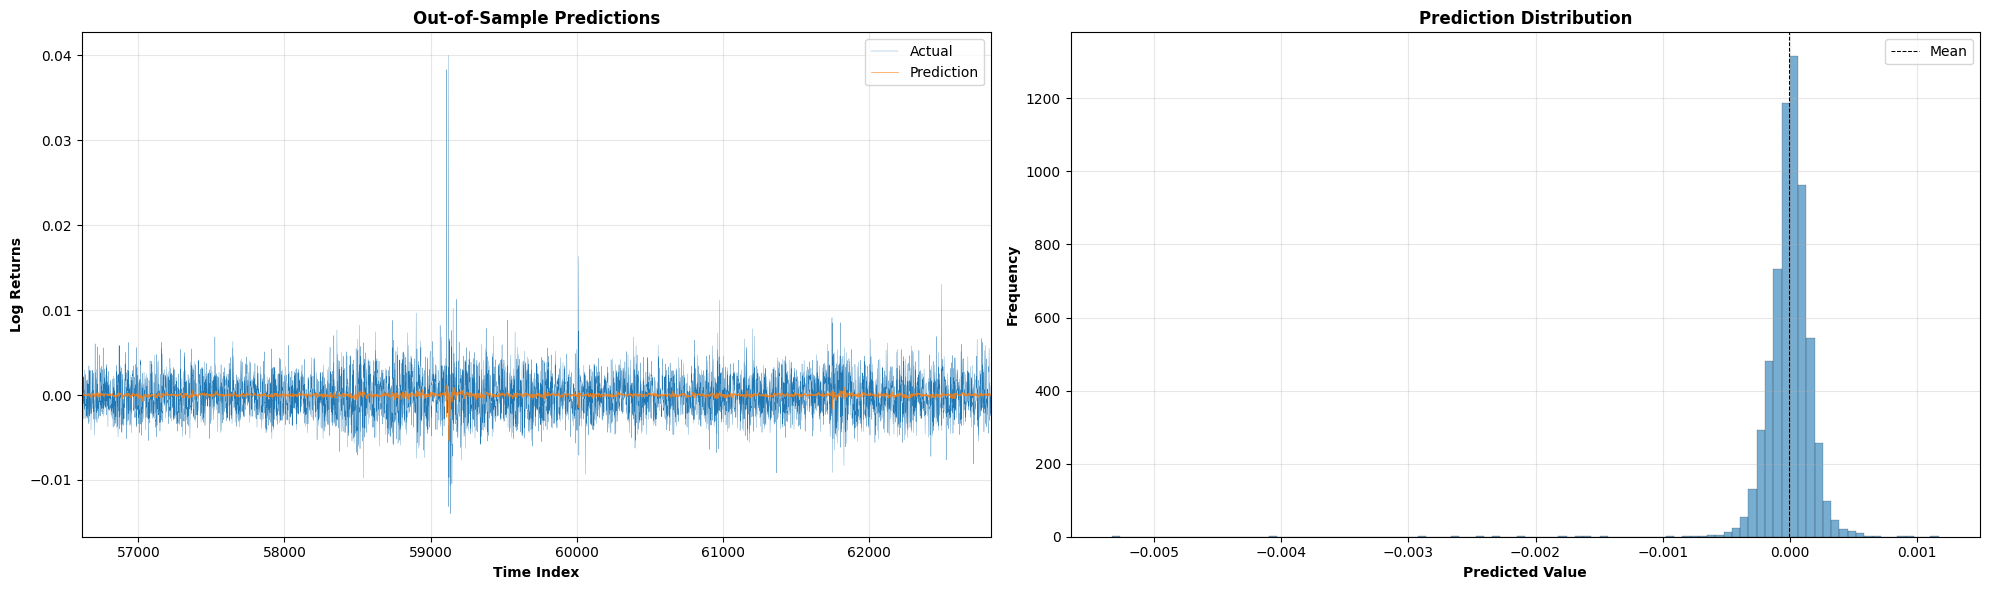

In [52]:
def plot_pred_analysis(data):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 6))

    # Time series
    ax1.plot(data.index, data['true'], label = 'Actual', lw = 0.2)
    ax1.plot(data.index, data['prediction'], label = 'Prediction', lw = 0.5, alpha = 0.8)

    ax1.set_title('Out-of-Sample Predictions', fontweight = 'bold')
    ax1.set_xlabel('Time Index', fontweight = 'bold')
    ax1.set_ylabel('Log Returns', fontweight = 'bold')

    ax1.set_xlim(data.index[0], data.index[-1])
    ax1.legend()
    ax1.grid(True, alpha = 0.3)

    # Histogram
    ax2.hist(data['prediction'], bins = 100, color = 'tab:blue', edgecolor = 'black', linewidth = 0.2, alpha = 0.6)
    ax2.axvline(data['prediction'].mean(), color = 'black', ls = '--', lw = 0.75, label = 'Mean')

    ax2.set_title('Prediction Distribution', fontweight = 'bold')
    ax2.set_xlabel('Predicted Value', fontweight = 'bold')
    ax2.set_ylabel('Frequency', fontweight = 'bold')

    ax2.legend()
    ax2.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

plot_pred_analysis(final_results['test_predictions'])

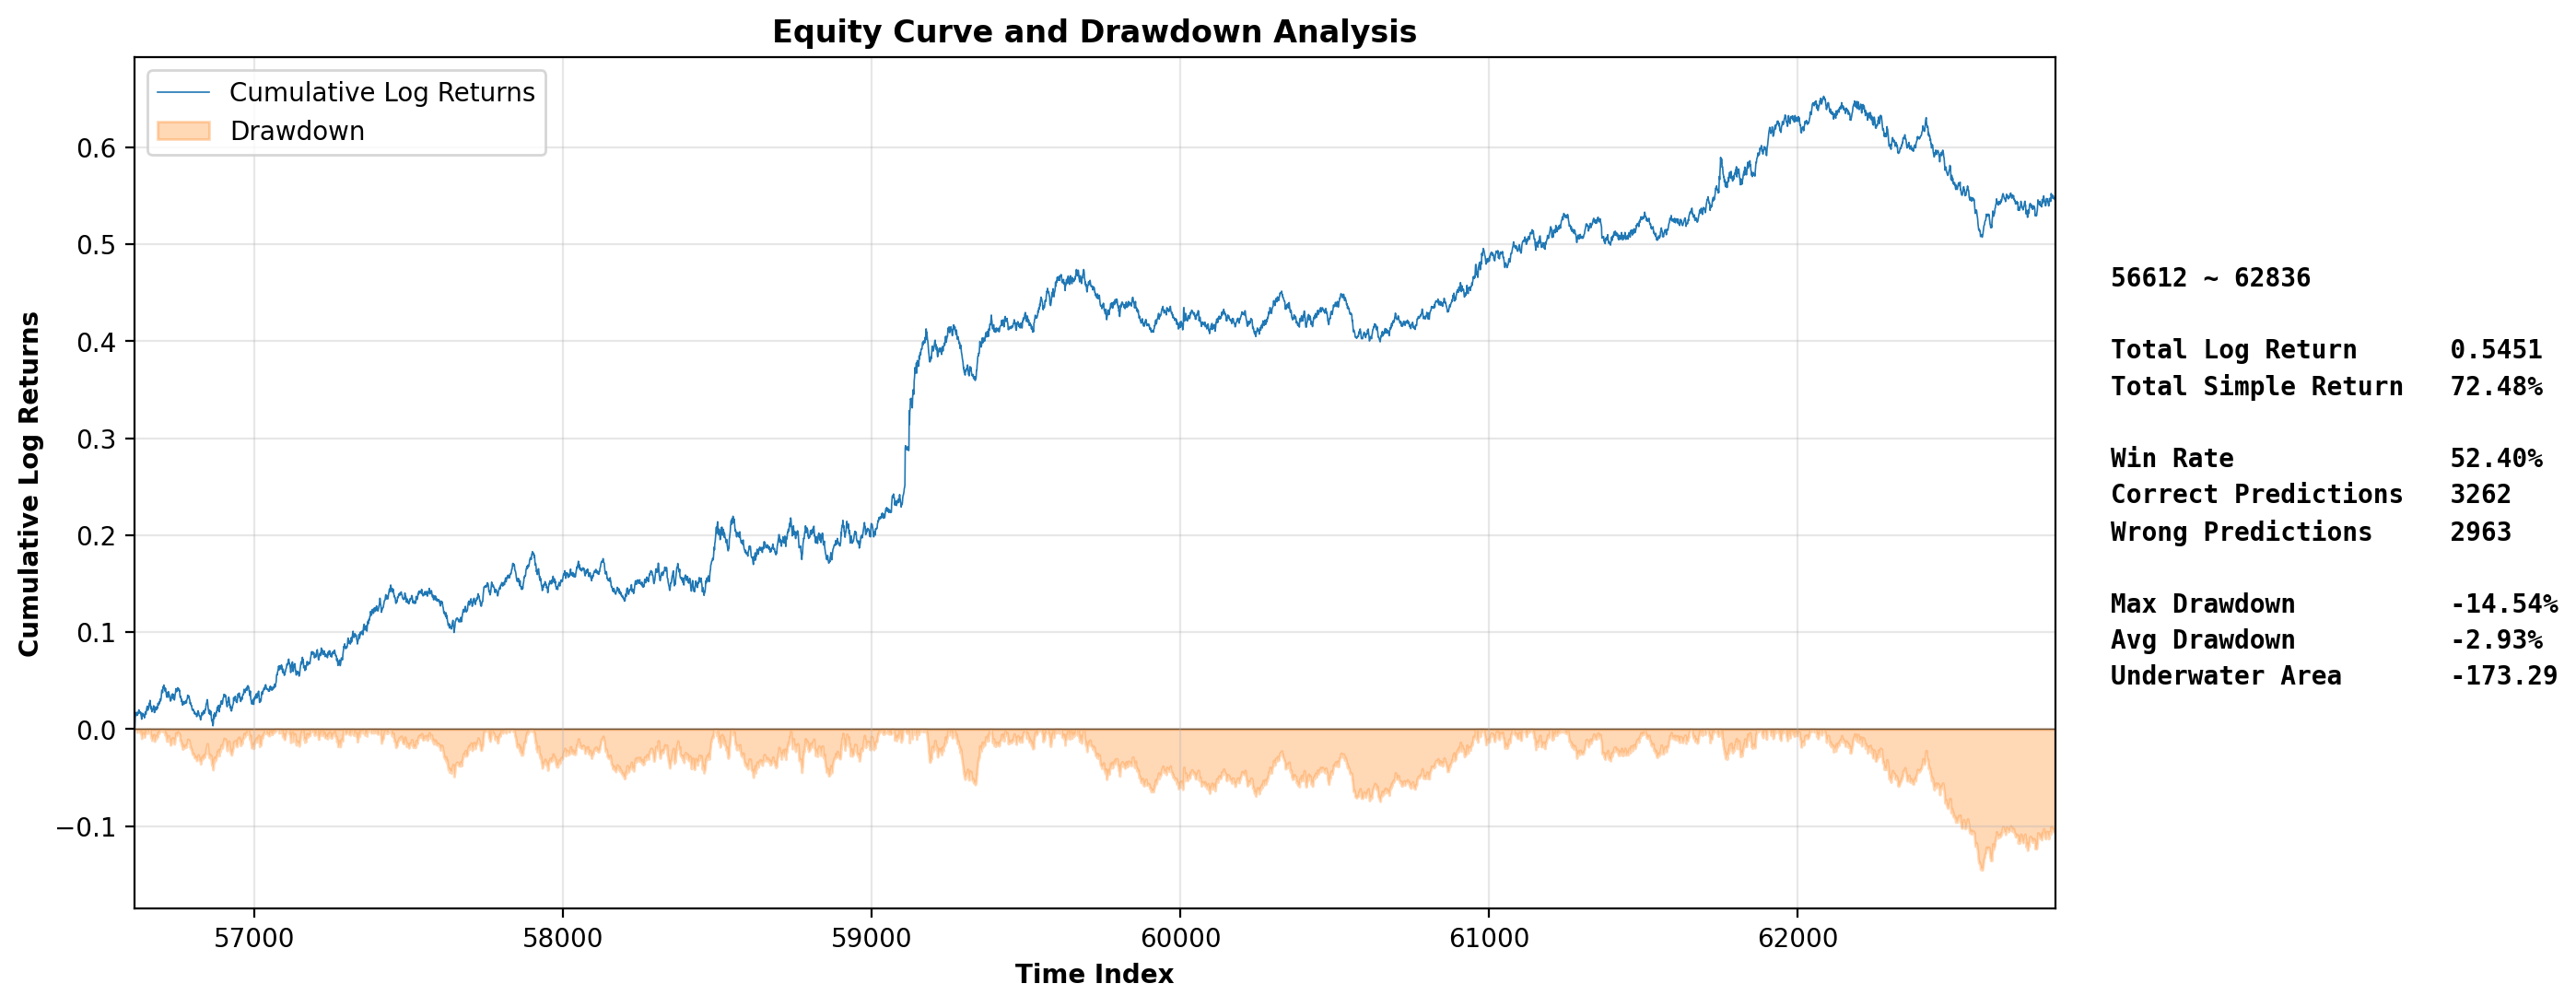

In [51]:
def plot_equity_curve(data):

    log_returns = np.where(data['prediction'] > 0, data['true'], -data['true'])
    cum_log_returns = np.cumsum(log_returns)

    running_max = np.maximum.accumulate(cum_log_returns)
    drawdown = cum_log_returns - running_max  # Drawdown calculation

    # Metrics calculation
    total_log_return = cum_log_returns[-1]
    total_simple_return = np.exp(total_log_return) - 1
    correct_predictions = np.sum(log_returns > 0)
    wrong_predictions = np.sum(log_returns <= 0)
    win_rate = correct_predictions / len(log_returns)

    max_drawdown = np.min(drawdown)
    avg_drawdown = np.mean(drawdown[drawdown < 0]) if np.any(drawdown < 0) else 0
    underwater_area = np.sum(drawdown)

    start_idx, end_idx = data.index[0], data.index[-1]
    date_str = f"{start_idx} ~ {end_idx}"

    fig, ax = plt.subplots(figsize = (15, 6), dpi = 200)
    ax.plot(data.index, cum_log_returns, lw = 0.6, color = 'tab:blue', label = 'Cumulative Log Returns', zorder = 2)
    ax.fill_between(data.index, drawdown, 0, color = 'tab:orange', alpha = 0.3, label = 'Drawdown', zorder = 1)

    ax.axhline(y = 0, color = 'black', linewidth = 0.5, zorder = 0)
    ax.set_xlim(data.index[0], data.index[-1])

    ax.set_title('Equity Curve and Drawdown Analysis', fontweight = 'bold')
    ax.set_xlabel('Time Index', fontweight = 'bold')
    ax.set_ylabel('Cumulative Log Returns', fontweight = 'bold')
    ax.legend(loc = 'best')
    ax.grid(True, alpha = 0.3)

    # Right side statistics panel
    stats_text = (f"{date_str}\n\n"
                  f"Total Log Return      {total_log_return:.4f}\n"
                  f"Total Simple Return   {total_simple_return:.2%}\n"
                  f"\n"
                  f"Win Rate              {win_rate:.2%}\n"
                  f"Correct Predictions   {correct_predictions}\n"
                  f"Wrong Predictions     {wrong_predictions}\n"
                  f"\n"
                  f"Max Drawdown          {max_drawdown:.2%}\n"
                  f"Avg Drawdown          {avg_drawdown:.2%}\n"
                  f"Underwater Area       {underwater_area:.2f}")

    fig.text(0.84, 0.5, stats_text, va = 'center', ha = 'left', fontsize = 10, family = 'monospace', linespacing = 1.5, fontweight = 'bold')

    plt.subplots_adjust(right = 0.82)
    plt.show()

metrics = plot_equity_curve(final_results['test_predictions'])
metrics

In [ ]:
evaluation_data = final_results['test_predictions'].copy()
evaluation_data['return'] = test['return']
# evaluation_data['return'] = (
#     (1.5 *  test['return']) + (1 * test['return'].shift(-1))
# )
evaluation_data

In [28]:
print('sum of return series:')
print('long:', long := evaluation_data.loc[evaluation_data['prediction'] > 0, 'return'].sum())
print('short:', short := evaluation_data.loc[evaluation_data['prediction'] < 0, 'return'].sum() * -1) # evaluation_data['prediction'].quantile(0.511)                                                                    #
print('total:', long + short)

sum of return series:
long: 0.08055944223748482
short: 0.46455928830841176
total: 0.5451187305458965


In [29]:
import math
math.exp(long + short) - 1

0.7248131582274664

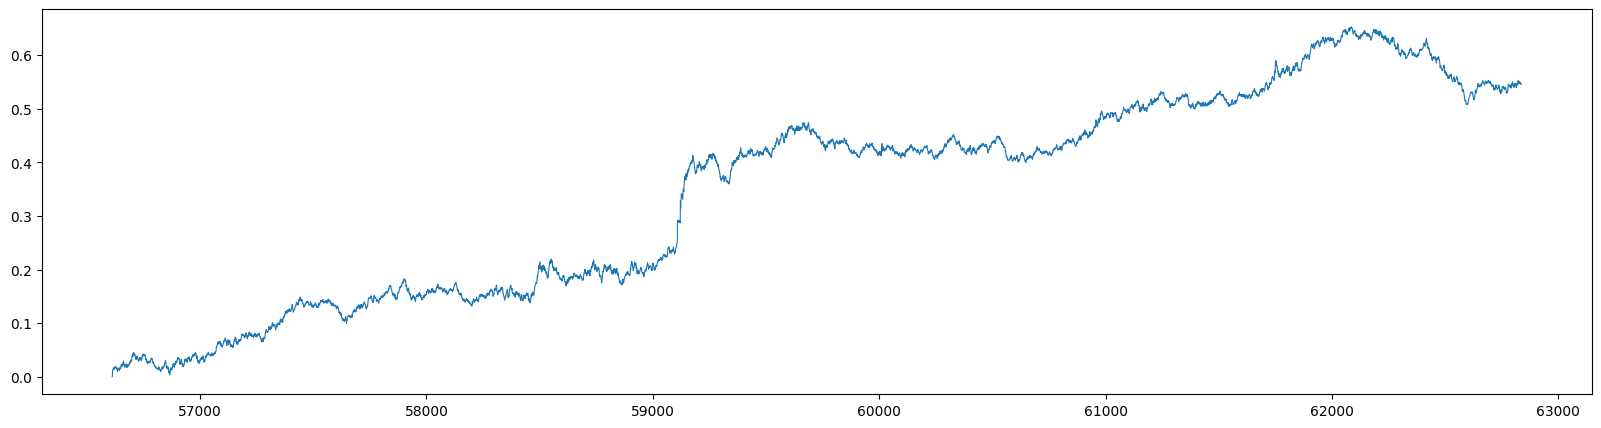

In [30]:
evaluation_data['plot'] = None
evaluation_data.loc[evaluation_data['prediction'] < 0, 'plot'] = evaluation_data.loc[evaluation_data['prediction'] < 0, 'return'] * -1
evaluation_data.loc[evaluation_data['prediction'] > 0, 'plot'] = evaluation_data.loc[evaluation_data['prediction'] > 0, 'return']
evaluation_data['plot'] = evaluation_data['plot'].cumsum()

plt.subplots(figsize = (20, 5))
plt.plot(evaluation_data['plot'], color = 'tab:blue', lw = 0.8, label = 'prediction')
plt.show()

In [31]:
# 对 true 的方向正确率
true_sign = np.sign(evaluation_data['true'])
pred_sign = np.sign(evaluation_data['prediction'])
return_sign = np.sign(evaluation_data['return'])

direction_accuracy_true = (true_sign == pred_sign).mean() * 100
print(f"1. 原始预测值对 true 的方向正确率: {direction_accuracy_true:.2f}%")

# 对 return 的方向正确率
direction_accuracy_return = (return_sign == pred_sign).mean() * 100
print(f"2. 原始预测值对 return 的方向正确率: {direction_accuracy_return:.2f}%")

1. 原始预测值对 true 的方向正确率: 52.40%
2. 原始预测值对 return 的方向正确率: 52.40%


In [ ]:
len(main_continuous_resampled_date_index)